# Flaring-Site Coverage Over Time

This is a time series view of flaring-site coverage: for each production month, what share of that
month's oil (`oil_sold_total_bbl`) and flared gas (`total_vented_flared_mcf`) comes from wells with a
real `site_id`, versus wells with `site_id == -1` (not associated with any known flaring/combustion
site)?

Each month is plotted as a 100%-stacked area — the two series always sum to 100% of that month's
volume.

**Source file:** `permian_prod_per_well_with_site_id.csv` — this pipeline's final well-level output,
saved as CSV rather than Parquet. This file can run into the tens of millions of well-month rows, so
rather than loading it whole into a single DataFrame and then grouping (memory-heavy for not much
benefit — the only thing we actually need out of it is the aggregated monthly sums), this notebook
streams it in fixed-size batches via `pandas.read_csv(..., chunksize=...)` and accumulates the
`(date, has_site)` sums incrementally, one batch at a time. Peak memory stays close to the size of a
single batch, not the size of the whole file.

Unlike Parquet, a CSV has no metadata header telling you the total row count up front (Parquet stores
that in its footer; CSV is just a stream of text), so this notebook doesn't print a total-row-count
preview the way a Parquet-based version could — the first real progress signal is the batch counter
printed while accumulating.

## 1. Setup and a Cheap Column Preview

Reads only the CSV header (`nrows=0`) to confirm the expected columns are present, without loading
any actual row data — the cheapest possible sanity check before committing to a full streaming pass
over a potentially large file.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from collections import defaultdict

WELLS_PATH = "../data/processed/texas/permian_only/permian_prod_per_well_with_site_id.csv"
COLS = ["date", "site_id", "oil_sold_total_bbl", "total_vented_flared_mcf"]
BATCH_SIZE = 1_000_000

header_only = pd.read_csv(WELLS_PATH, nrows=0)
print("Columns available:", header_only.columns.tolist())
missing = [c for c in COLS if c not in header_only.columns]
if missing:
    raise ValueError(f"Expected columns not found in {WELLS_PATH}: {missing}")
print(f"✓ All {len(COLS)} needed columns are present.")


Columns available: ['operator_no', 'oil_pipeline_bbl', 'oil_truck_bbl', 'oil_tankcar_bbl', 'oil_tank_cleaning_bbl', 'oil_circulating_bbl', 'oil_lost_stolen_bbl', 'oil_bsw_repressure_bbl', 'oil_legacy_bbl', 'oil_skimmed_bbl', 'oil_scrubber_bbl', 'oil_no_disp_code_bbl', 'csgd_field_ops_fuel_mcf', 'csgd_transmission_mcf', 'csgd_processing_plant_mcf', 'csgd_vented_flared_mcf', 'csgd_gas_lift_mcf', 'csgd_repressure_mcf', 'csgd_carbon_black_mcf', 'csgd_underground_storage_mcf', 'csgd_no_disp_code_mcf', 'oil_sold_total_bbl', 'total_vented_flared_mcf', 'date', 'lease_key', 'api8', 'longitude', 'latitude', 'n_wells_with_coordinates', 'site_id', 'geometry_wkt']
✓ All 4 needed columns are present.


## 2. Stream the CSV in Batches and Accumulate Monthly Sums

`pandas.read_csv(..., chunksize=BATCH_SIZE, usecols=COLS)` returns an iterator that reads
`BATCH_SIZE` rows at a time directly off disk — only the four columns listed in `COLS` are parsed out
of each row, and `date` is parsed straight into a proper datetime. For each batch:

1. Tag every row `has_site = (site_id != -1)`.
2. Group by `(date, has_site)` and sum `oil_sold_total_bbl` / `total_vented_flared_mcf` for just this
   batch.
3. Add those partial sums into a running accumulator dictionary keyed by `(date, has_site)`.

Once every batch has been processed, the accumulator already holds the full monthly totals — no
batch's raw rows are ever kept around after it's been summed.

In [2]:
# Accumulate (date, has_site) -> [oil_sum, flare_sum] one batch at a time, instead of
# materializing the full multi-million-row table before grouping.
acc = defaultdict(lambda: [0.0, 0.0])

reader = pd.read_csv(WELLS_PATH, usecols=COLS, parse_dates=["date"], chunksize=BATCH_SIZE)

for i, chunk in enumerate(reader, 1):
    chunk["has_site"] = chunk["site_id"] != -1
    grouped = (
        chunk.groupby(["date", "has_site"], observed=True)[["oil_sold_total_bbl", "total_vented_flared_mcf"]]
        .sum()
    )
    for (date, has_site), row in grouped.iterrows():
        entry = acc[(date, has_site)]
        entry[0] += row["oil_sold_total_bbl"]
        entry[1] += row["total_vented_flared_mcf"]
    print(f"  batch {i:3d}: {len(chunk):,} rows processed (cumulative months seen: {len({k[0] for k in acc}):,})")

monthly = pd.DataFrame(
    [(date, has_site, vals[0], vals[1]) for (date, has_site), vals in acc.items()],
    columns=["date", "has_site", "oil_sold_total_bbl", "total_vented_flared_mcf"],
).sort_values("date")

print(f"\nAggregated to {monthly['date'].nunique()} months")
monthly.head()


  batch   1: 1,000,000 rows processed (cumulative months seen: 11)
  batch   2: 1,000,000 rows processed (cumulative months seen: 11)
  batch   3: 1,000,000 rows processed (cumulative months seen: 23)
  batch   4: 1,000,000 rows processed (cumulative months seen: 23)
  batch   5: 1,000,000 rows processed (cumulative months seen: 35)
  batch   6: 1,000,000 rows processed (cumulative months seen: 35)
  batch   7: 1,000,000 rows processed (cumulative months seen: 47)
  batch   8: 1,000,000 rows processed (cumulative months seen: 47)
  batch   9: 1,000,000 rows processed (cumulative months seen: 59)
  batch  10: 1,000,000 rows processed (cumulative months seen: 59)
  batch  11: 1,000,000 rows processed (cumulative months seen: 59)
  batch  12: 1,000,000 rows processed (cumulative months seen: 71)
  batch  13: 1,000,000 rows processed (cumulative months seen: 71)
  batch  14: 1,000,000 rows processed (cumulative months seen: 83)
  batch  15: 1,000,000 rows processed (cumulative months seen:

,date,has_site,oil_sold_total_bbl,total_vented_flared_mcf
0,2012-02-01,False,2.375201e+07,6.924262e+05
1,2012-02-01,True,3.953099e+06,2.156592e+05
2,2012-03-01,False,2.545033e+07,7.932735e+05
3,2012-03-01,True,4.231891e+06,3.264148e+05
4,2012-04-01,False,2.509379e+07,1.070921e+06


<Axes: >

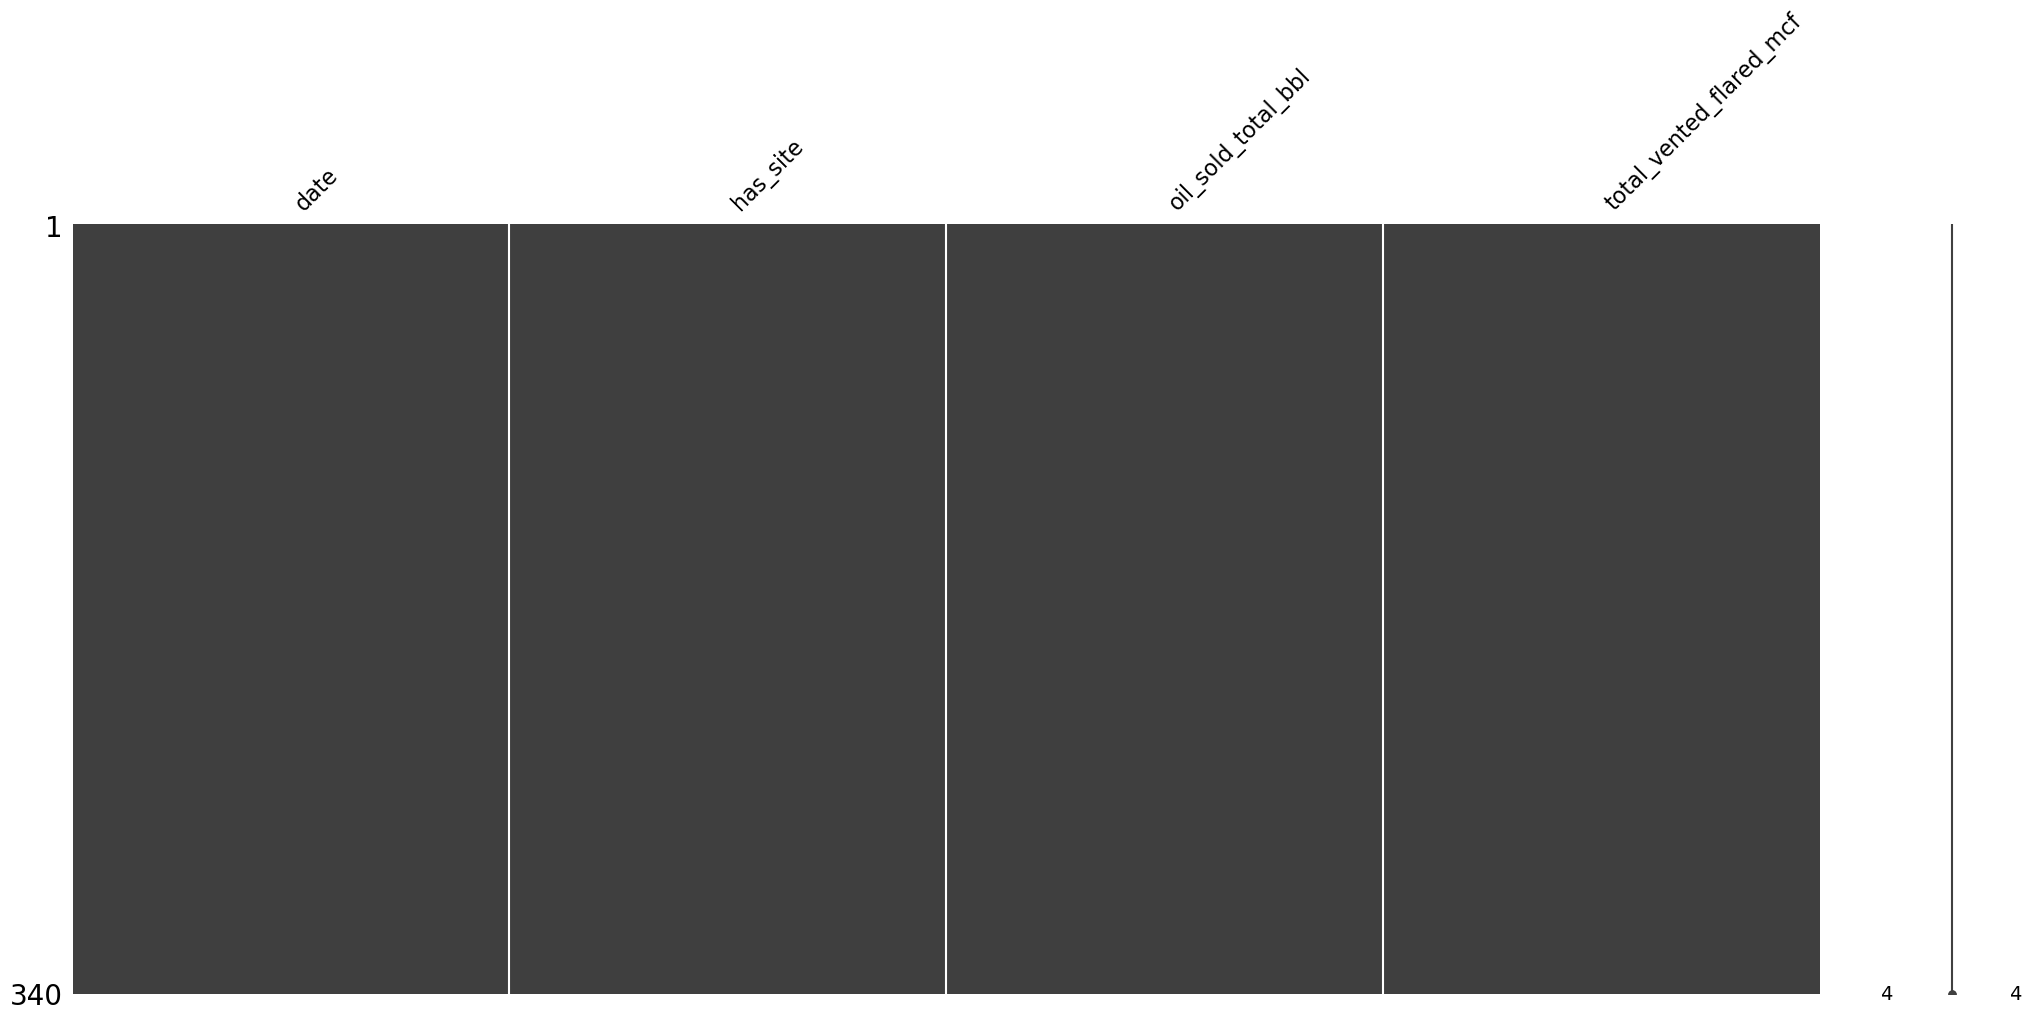

In [3]:
import missingno as msn
msn.matrix(monthly)

## 3. Convert to Monthly Percentages

Pivots the accumulated sums so each month has one "no site" column and one "has site" column, then
converts both oil and flared-gas sums to a percentage of that month's total — this is what turns the
data into something plottable as a 100%-stacked area, where every month sums to exactly 100%.

In [4]:
oil_pivot = monthly.pivot(index="date", columns="has_site", values="oil_sold_total_bbl").fillna(0)
flare_pivot = monthly.pivot(index="date", columns="has_site", values="total_vented_flared_mcf").fillna(0)

oil_pivot.columns = ["No site_id (-1)", "Has site_id"]
flare_pivot.columns = ["No site_id (-1)", "Has site_id"]

# Convert to % of that month's total
oil_pct = oil_pivot.div(oil_pivot.sum(axis=1), axis=0) * 100
flare_pct = flare_pivot.div(flare_pivot.sum(axis=1), axis=0) * 100

oil_pct.tail()


,No site_id (-1),Has site_id
date,,
2025-11-01,74.641886,25.358114
2025-12-01,75.582099,24.417901
2026-01-01,76.046527,23.953473
2026-02-01,76.870237,23.129763
2026-03-01,76.932750,23.067250


## 4. Plot: Oil and Flared Gas Coverage, Side by Side

Two stacked-area subplots, sharing a time axis: the top shows what share of each month's *oil*
volume came from wells with vs. without a flaring-site match; the bottom shows the same for *flared
gas* volume. The plot is also saved to disk as a PNG.

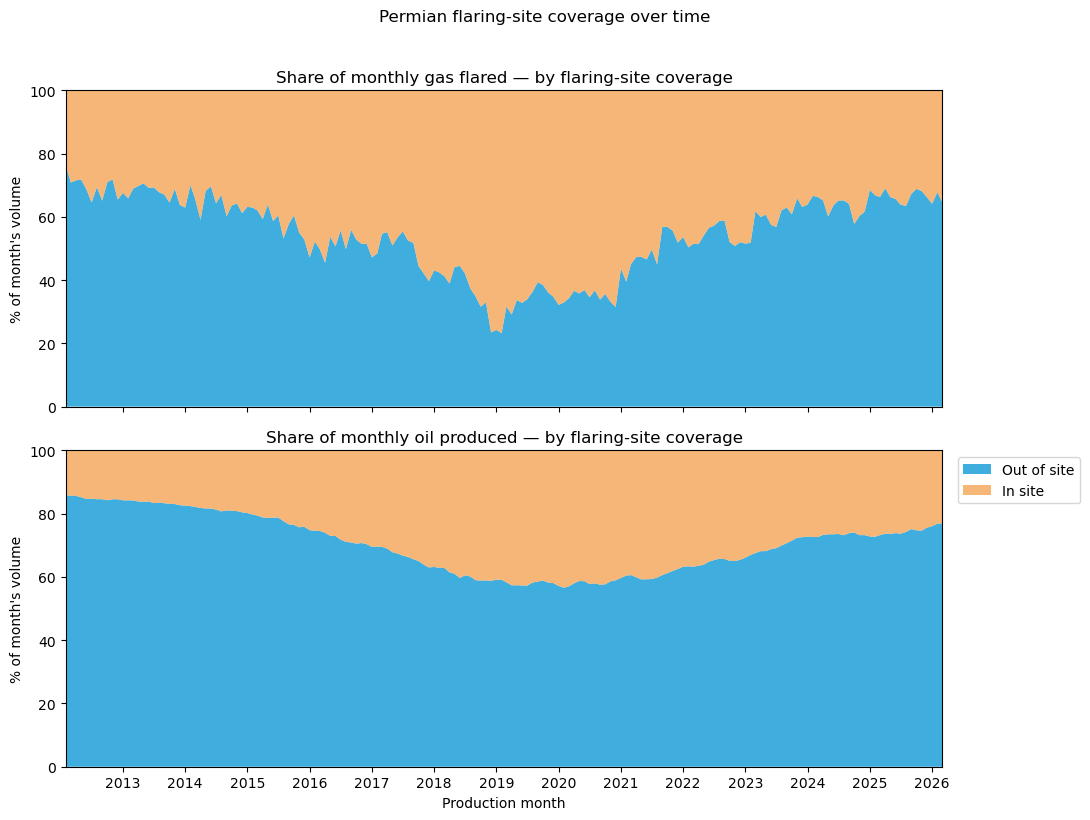

In [16]:
fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)

colors = ["#1da0d9", "#f4a95f"]  # No site_id, Has site_id

for ax, pct, title in zip(axes, [flare_pct, oil_pct], ["Gas flared","Oil produced"]):
    ax.stackplot(
        pct.index,
        pct["No site_id (-1)"], pct["Has site_id"],
        labels=["Out of site", "In site"],
        colors=colors, alpha=0.85,
    )
    ax.set_title(f"Share of monthly {title.lower()} — by flaring-site coverage")
    ax.set_ylabel("% of month's volume")
    ax.set_ylim(0, 100)
    ax.margins(x=0)

axes[-1].legend(loc="upper left", bbox_to_anchor=(1.01, 1))
axes[-1].xaxis.set_major_locator(mdates.YearLocator())
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[-1].set_xlabel("Production month")

fig.suptitle("Permian flaring-site coverage over time", y=1.02)
fig.tight_layout()
plt.savefig("../results/site_id_coverage_over_time.png", dpi=150, bbox_inches="tight")
plt.show()


In [17]:
total_oil_site = oil_pivot["Has site_id"].sum()
total_oil_all = oil_pivot.sum().sum()
print(f"{total_oil_site / total_oil_all:.2%} of total oil (2012–2026) came from wells matched to a VIIRS site")

31.67% of total oil (2012–2026) came from wells matched to a VIIRS site


In [18]:
peak_date = oil_pct["Has site_id"].idxmax()
peak_value = oil_pct["Has site_id"].max()
print(f"Peak site-matched oil share: {peak_value:.2f}% in {peak_date:%B %Y}")

Peak site-matched oil share: 43.38% in February 2020


## 5. Absolute Volumes: Whole Region vs. Site-Matched Wells Only

Section 3 already pivoted the accumulated monthly sums into `oil_pivot` and `flare_pivot`, each with
a `"No site_id (-1)"` column and a `"Has site_id"` column — so no re-reading of the file is needed
here.

- **Whole region** = every well, matched or not (`"No site_id (-1)"` + `"Has site_id"` summed
  together).
- **Site-matched wells only** = just the `"Has site_id"` column.

Oil (`oil_sold_total_bbl`, in BBL) and flared gas (`total_vented_flared_mcf`, in MCF) are plotted
together on the same panel using a second y-axis, since the two series are in different units and on
very different scales. Two panels, side by side, sharing a time axis: left is the whole region, right
is site-matched wells only — so any difference in shape or scale between the two populations is
visible directly.

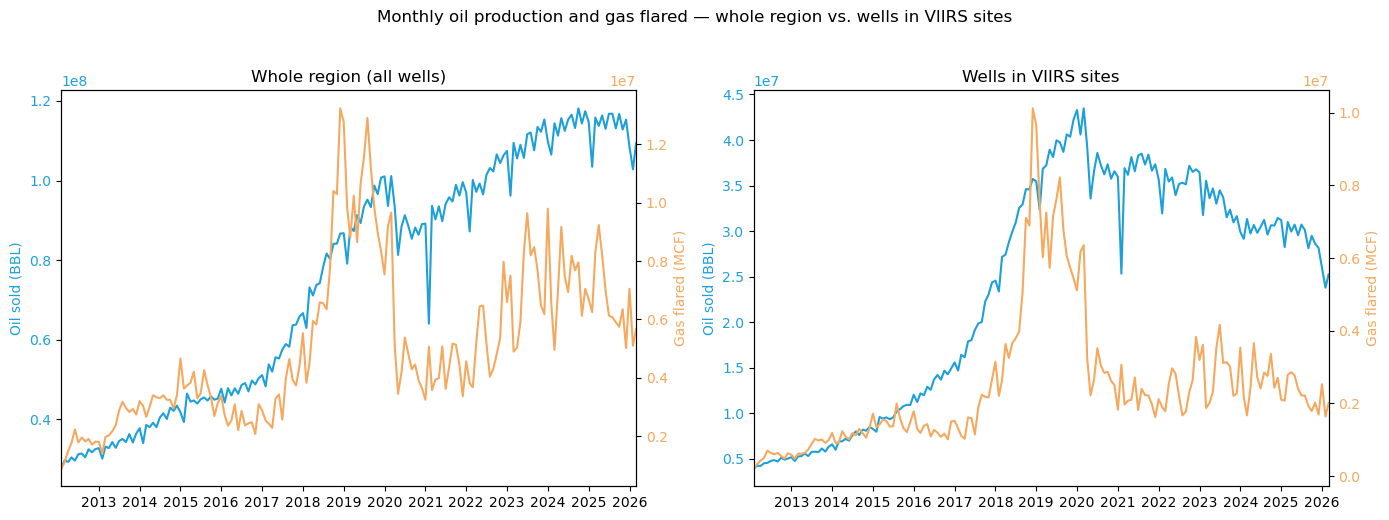

In [6]:
oil_region = oil_pivot.sum(axis=1)
flare_region = flare_pivot.sum(axis=1)
oil_site = oil_pivot["Has site_id"]
flare_site = flare_pivot["Has site_id"]

oil_color, gas_color = "#1da0d9", "#f4a95f"

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

panels = [
    ("Whole region (all wells)", oil_region, flare_region),
    ("Wells in VIIRS sites", oil_site, flare_site),
]

for ax, (title, oil_series, flare_series) in zip(axes, panels):
    ax.plot(oil_series.index, oil_series.values, color=oil_color, label="Oil sold (BBL)")
    ax.set_ylabel("Oil sold (BBL)", color=oil_color)
    ax.tick_params(axis="y", labelcolor=oil_color)

    ax2 = ax.twinx()
    ax2.plot(flare_series.index, flare_series.values, color=gas_color, label="Gas flared (MCF)")
    ax2.set_ylabel("Gas flared (MCF)", color=gas_color)
    ax2.tick_params(axis="y", labelcolor=gas_color)

    ax.set_title(title)
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.margins(x=0)

fig.suptitle("Monthly oil production and gas flared \u2014 whole region vs. wells in VIIRS sites", y=1.03)
fig.tight_layout()
plt.savefig("../results/eda/oil_and_flare_region_vs_site.png", dpi=150, bbox_inches="tight")
plt.show()


## 6. Gas Flared vs. Oil Sold: Whole Region vs. Site-Matched Wells Only

A scatter of the two volumes directly against each other, one point per production month: **oil sold
on the x-axis, gas flared on the y-axis**. This shows the shape of the relationship between the two
(e.g. whether flaring tends to scale up with oil production, or is roughly flat regardless of oil
volume) rather than collapsing it into a single ratio number. Same two-panel split as Section 5:
whole region on the left, site-matched wells only on the right — reusing `oil_region`/`flare_region`
and `oil_site`/`flare_site` computed there.

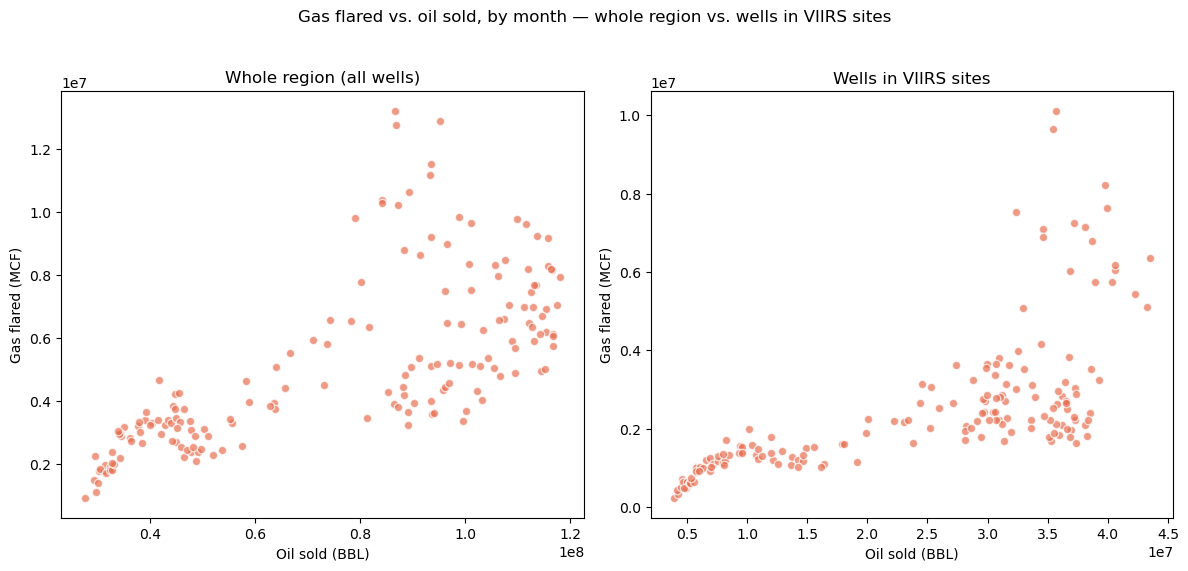

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))

panels = [
    ("Whole region (all wells)", oil_region, flare_region),
    ("Wells in VIIRS sites", oil_site, flare_site),
]

for ax, (title, oil_series, flare_series) in zip(axes, panels):
    ax.scatter(oil_series.values, flare_series.values, color="#e76f51", alpha=0.7, edgecolor="white")
    ax.set_title(title)
    ax.set_xlabel("Oil sold (BBL)")
    ax.set_ylabel("Gas flared (MCF)")

fig.suptitle("Gas flared vs. oil sold, by month \u2014 whole region vs. wells in VIIRS sites", y=1.03)
fig.tight_layout()
plt.savefig("../results/eda/gas_vs_oil_region_vs_site.png", dpi=150, bbox_inches="tight")
plt.show()
